In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✅")

Libraries loaded ✅


In [60]:
ad_spend = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Row\ad_spend_data.csv')
web_log = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Row\web_analytics_log.csv')
crm = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Row\crm_conversion_data.csv')

print("Ad Spend Shape:", ad_spend.shape)
print("Web Log Shape:", web_log.shape)
print("CRM Shape:", crm.shape)
print("\nData Loaded ✅")

Ad Spend Shape: (1350, 7)
Web Log Shape: (6034, 10)
CRM Shape: (600, 7)

Data Loaded ✅


In [62]:
print("AD SPEND columns:", list(ad_spend.columns))
print("WEB LOG columns:", list(web_log.columns))
print("CRM columns:", list(crm.columns))

AD SPEND columns: ['date', 'channel', 'campaign', 'amount_spent_usd', 'clicks', 'impressions', 'cpc']
WEB LOG columns: ['session_id', 'user_id', 'timestamp', 'channel', 'utm_source', 'utm_medium', 'utm_campaign', 'page_visited', 'session_duration_sec', 'device']
CRM columns: ['customer_id', 'conversion_date', 'revenue_usd', 'last_touch_channel', 'last_touch_campaign', 'product_purchased', 'country']


In [64]:
print("=== AD SPEND ===")
print(ad_spend.head())
print("\n=== WEB LOG ===")
print(web_log.head())
print("\n=== CRM ===")
print(crm.head())

=== AD SPEND ===
         date        channel            campaign  amount_spent_usd  clicks  \
0  2024-01-01  Google_Search       GSearch_Brand           2098.57    3730   
1  2024-01-01  Google_Search     GSearch_Generic           1112.23    1310   
2  2024-01-01  Google_Search  GSearch_Competitor           2191.75     802   
3  2024-01-01  Meta_Facebook      FB_Retargeting           1303.84    2250   
4  2024-01-01  Meta_Facebook        FB_Lookalike            671.68     380   

   impressions    cpc  
0       100710  0.563  
1        20960  0.849  
2        12030  2.733  
3        33750  0.579  
4         4180  1.768  

=== WEB LOG ===
   session_id    user_id            timestamp        channel utm_source  \
0  SES_323717  USR_00001  2024-03-07 21:21:00  Meta_Facebook   facebook   
1  SES_352023  USR_00002  2024-03-27 20:39:00        Organic    organic   
2  SES_396567  USR_00002  2024-03-25 00:58:00  Meta_Facebook   facebook   
3  SES_638857  USR_00003  2024-03-13 02:06:00  Meta_F

In [66]:
print("=== NULL VALUES ===")
print("\nAd Spend:")
print(ad_spend.isnull().sum())
print("\nWeb Log:")
print(web_log.isnull().sum())
print("\nCRM:")
print(crm.isnull().sum())

=== NULL VALUES ===

Ad Spend:
date                0
channel             0
campaign            0
amount_spent_usd    0
clicks              0
impressions         0
cpc                 0
dtype: int64

Web Log:
session_id                0
user_id                   0
timestamp                 0
channel                   0
utm_source              600
utm_medium                0
utm_campaign            299
page_visited              0
session_duration_sec      0
device                    0
dtype: int64

CRM:
customer_id             0
conversion_date         0
revenue_usd             0
last_touch_channel      0
last_touch_campaign    33
product_purchased       0
country                 0
dtype: int64


In [68]:
web_log['utm_source'] = web_log['utm_source'].fillna('unknown')
web_log['utm_campaign'] = web_log['utm_campaign'].fillna('unknown')

print("Nulls Fixed ✅")
print(web_log.isnull().sum())

Nulls Fixed ✅
session_id              0
user_id                 0
timestamp               0
channel                 0
utm_source              0
utm_medium              0
utm_campaign            0
page_visited            0
session_duration_sec    0
device                  0
dtype: int64


In [70]:
web_log['timestamp'] = pd.to_datetime(web_log['timestamp'], utc=True)
crm['conversion_date'] = pd.to_datetime(crm['conversion_date'])
ad_spend['date'] = pd.to_datetime(ad_spend['date'])

print("Timestamps Fixed ✅")

Timestamps Fixed ✅


In [72]:
import os
os.makedirs(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs', exist_ok=True)
print("Outputs folder ready ✅")

Outputs folder ready ✅


In [74]:
print("Before:")
print("Web Log:", web_log.shape)

web_log = web_log.drop_duplicates()
crm = crm.drop_duplicates()
ad_spend = ad_spend.drop_duplicates()

print("After:")
print("Web Log:", web_log.shape)
print("Duplicates Removed ✅")

Before:
Web Log: (6034, 10)
After:
Web Log: (6034, 10)
Duplicates Removed ✅


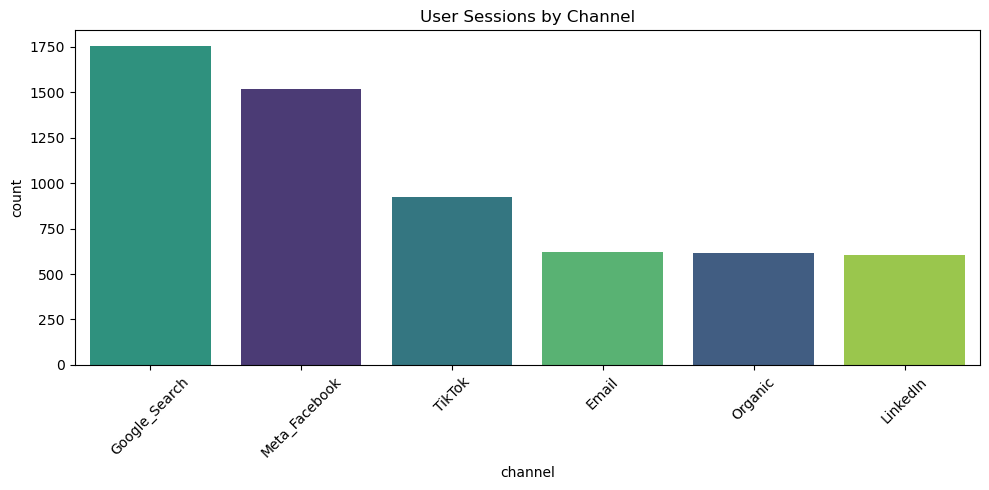

Graph 1 Saved ✅


In [76]:
plt.figure(figsize=(10,5))
sns.countplot(data=web_log, x='channel',
              order=web_log['channel'].value_counts().index,
              hue='channel',
              legend=False,
              palette='viridis')
plt.title('User Sessions by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs\channel_distribution.png')
plt.show()
print("Graph 1 Saved ✅")

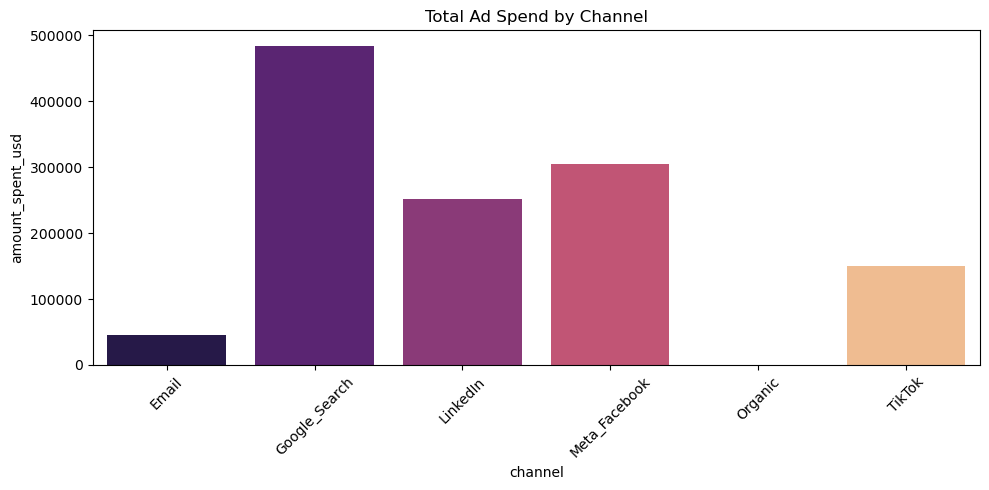

Graph 2 Saved ✅


In [78]:
plt.figure(figsize=(10,5))
spend = ad_spend.groupby('channel')['amount_spent_usd'].sum().reset_index()
sns.barplot(data=spend, x='channel', y='amount_spent_usd',
            hue='channel',
            legend=False,
            palette='magma')
plt.title('Total Ad Spend by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs\ad_spend_by_channel.png')
plt.show()
print("Graph 2 Saved ✅")

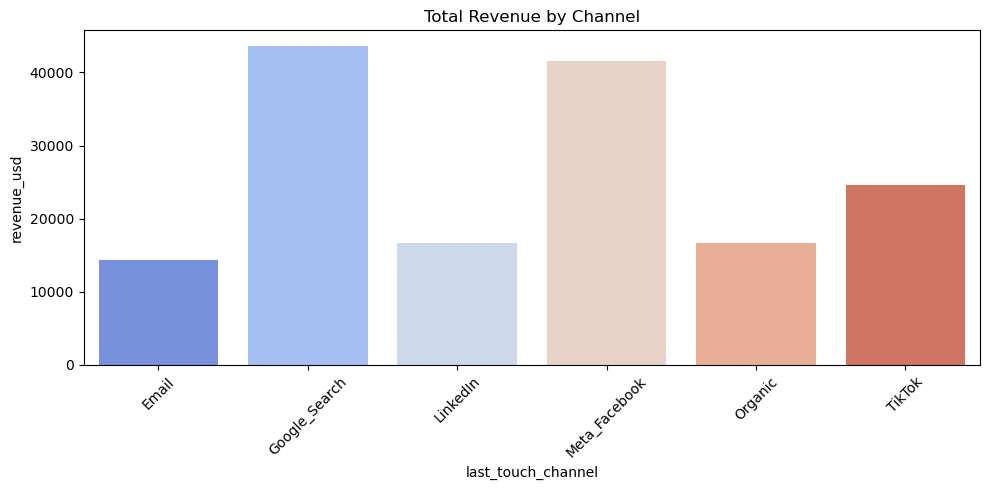

Graph 3 Saved ✅


In [80]:
plt.figure(figsize=(10,5))
revenue = crm.groupby('last_touch_channel')['revenue_usd'].sum().reset_index()
sns.barplot(data=revenue, x='last_touch_channel', y='revenue_usd',
            hue='last_touch_channel',
            legend=False,
            palette='coolwarm')
plt.title('Total Revenue by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs\revenue_by_channel.png')
plt.show()
print("Graph 3 Saved ✅")